<a href="https://colab.research.google.com/github/arthireddy14/Machine_Learning/blob/main/all_data_hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('all-data.csv',encoding='latin1')
df

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...
...,...,...
4840,negative,LONDON MarketWatch -- Share prices ended lower...
4841,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4842,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4843,negative,Net sales of the Paper segment decreased to EU...


In [5]:
df.isna().sum()

,0
neutral,0
"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0


A media company publishes thousands of news articles daily.
Problems they face:
Articles are not consistently tagged
Manual categorization is expensive
New topics emerge frequently
The company wants to:
Automatically group similar news articles
Discover hidden themes without defining categories upfront
Build a content recommendation system
They hire you as a Data Analyst to discover natural article groupings using data — without knowing how many topics exist.

1️⃣ Data Understanding & Feature Selection
Load the dataset
Identify the column containing news text
Ignore any sentiment or category labels
Task:
Convert text into numerical form using TF-IDF
Limit features to a reasonable size (e.g., top 500–1000 words)


In [6]:
df.head()

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                           --------------  ----- 
 0   neutral                                                                                                                          4845 non-null   object
 1   According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .  4845 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [8]:
df.columns=['sentiment','text']

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,        # limit to top 1000 words
    stop_words='english',     # remove common stopwords
    lowercase=True
    # max_df=0.8
    # min_df=5
)

x = vectorizer.fit_transform(df['text'])  # replace with actual column name

Dendrogram Construction & Analysis
Build a dendrogram using a subset of articles
Observe:
Where large vertical jumps occur
What they indicate about topic separation

In [10]:
x_subset=x[:300].toarray()

In [16]:
print(type(x))
print(x.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(4845, 1000)


In [17]:
x_dense=x.toarray()

In [18]:
# from sklearn.decomposition import TruncatedSVD

# svd = TruncatedSVD(n_components=100)   # reduce to 100 features
# X_reduced = svd.fit_transform(x)

# linkage_matrix = sch.linkage(X_reduced, method='ward')

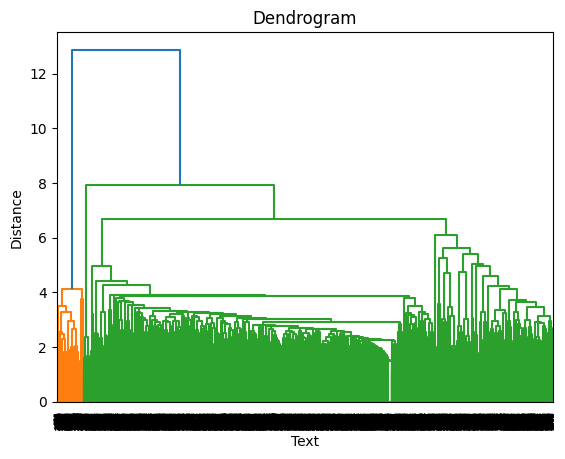

In [19]:
from scipy.cluster.hierarchy import dendrogram,linkage
import scipy.cluster.hierarchy as sch
linkage_matrix=sch.linkage(x_dense,method='ward')
dendrogram=sch.dendrogram(linkage_matrix)
plt.title('Dendrogram')
plt.xlabel('Text')
plt.ylabel('Distance')
plt.show()


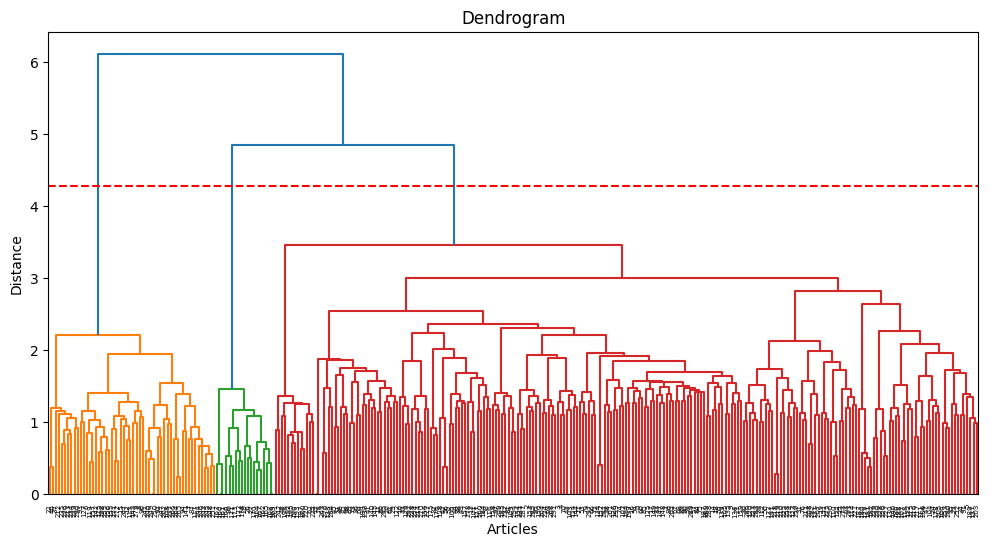

In [33]:
from scipy.cluster.hierarchy import dendrogram,linkage
z=linkage(x_subset,method='ward')
# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(z)
max_dist = max(z[:,2])
plt.axhline(y=max_dist*0.7,color='r',linestyle='--')
plt.title("Dendrogram")
plt.xlabel("Articles")
plt.ylabel("Distance")
plt.show()

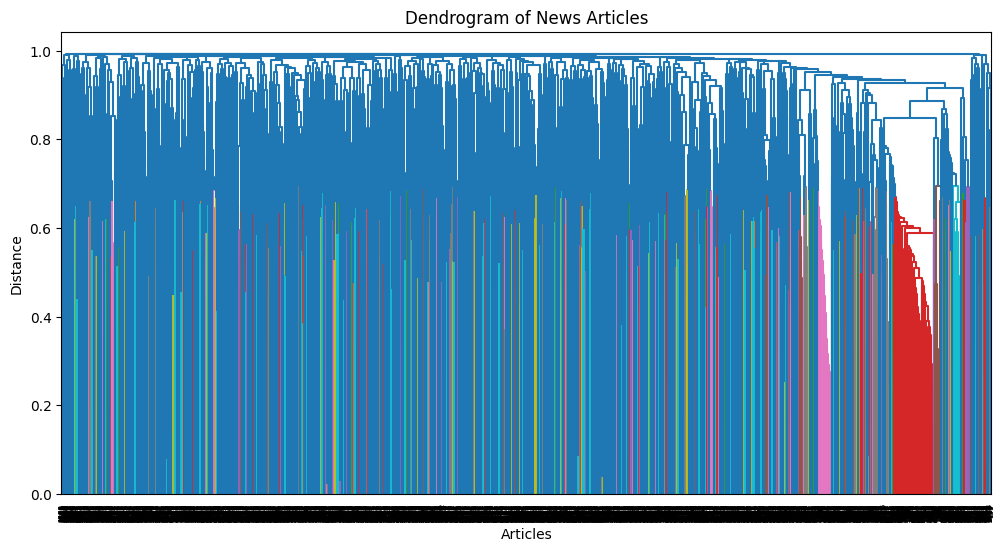

In [40]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
# Remove zero vectors if using cosine metric
# row_norms = np.linalg.norm(x, axis=1)
# x = x[row_norms != 0]
# # Perform hierarchical clustering
# linkage_matrix = sch.linkage(x, method='average',metric='cosine')
linkage_matric=sch.linkage(x,method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(linkage_matrix)

plt.title('Dendrogram of News Articles')
plt.xlabel('Articles')
plt.ylabel('Distance')   # "Distance" is more accurate than "Count"
plt.show()

Apply Hierarchical Clustering
Use Agglomerative Hierarchical Clustering
Choose an appropriate linkage method

Validation Without Labels (Critical Thinking)
Since this is unsupervised:
How do you judge clustering quality?
mertic:
Silhouette score


In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

clusters = model.fit_predict(x.toarray())

df["Cluster"] = clusters


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x.toarray(), clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.006827686825189129


In [ ]:
for k in range(2, 10):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(x.toarray())
    score = silhouette_score(x.toarray(), labels)
    print(f"K={k}, Silhouette Score={score}")


K=2, Silhouette Score=0.008956296747978341
K=3, Silhouette Score=0.008799251834791532
K=4, Silhouette Score=0.009879031329131593
K=5, Silhouette Score=0.006827686825189129
K=6, Silhouette Score=0.007596090630218961
K=7, Silhouette Score=0.006647798495830565
K=8, Silhouette Score=0.0072225666625097655
K=9, Silhouette Score=0.006742555928718986


we can choose k=4 because its silhoutte value is high